In [3]:
import pandas as pd
import psycopg
import os
from dotenv import load_dotenv
from db import JDBC_URL, conn_string

load_dotenv()

PG_HOST     = os.environ.get("DB_HOST")
PG_PORT     = os.environ.get("DB_PORT")
PG_DB       = os.environ.get("DB_DATABASE")
PG_USER     = os.environ.get("DB_USERNAME")
PG_PASSWORD = os.environ.get("DB_PASSWORD")

conn_string = f"host={PG_HOST} port={PG_PORT} dbname={PG_DB} user={PG_USER} password={PG_PASSWORD}"

conn = psycopg.connect(conn_string)
df = pd.read_sql('SELECT * FROM public_gold.fact_rates LIMIT 100', conn)
df.head()

C:\Users\Tanel\AppData\Local\Temp\ipykernel_47592\590923641.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('SELECT * FROM public_gold.fact_rates LIMIT 100', conn)


,date_key,curr_base,currency,rate
0,20260319070316,TWD,DZD,4.150865
1,20260319070316,TWD,GIP,0.023367
2,20260319070316,TWD,MWK,54.490015
3,20260319070316,TWD,HNL,0.832620
4,20260319070316,TWD,MXN,0.556139


In [4]:
query = """
SELECT d.date, f.curr_base, f.currency, f.rate
FROM public_gold.fact_rates f
JOIN public_gold.dim_date d ON f.date_key = d.date_key
LIMIT 1000
"""
df = pd.read_sql(query, conn)
# df.head()
print(len(df))
df

1000


C:\Users\Tanel\AppData\Local\Temp\ipykernel_47592\767658636.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,date,curr_base,currency,rate
0,2026-03-19 19:20:16,TWD,DZD,4.150865
1,2026-03-19 19:20:16,TWD,GIP,0.023367
2,2026-03-19 19:20:16,TWD,MWK,54.490015
3,2026-03-19 19:20:16,TWD,HNL,0.832620
4,2026-03-19 19:20:16,TWD,MXN,0.556139
...,...,...,...,...
995,2026-03-19 19:20:04,ANG,RUB,47.738813
996,2026-03-19 19:20:04,ANG,LYD,3.539747
997,2026-03-19 19:20:04,ANG,MOP,4.475726
998,2026-03-19 19:20:04,ANG,MUR,25.800680


<Axes: title={'center': 'EUR to USD Exchange Rate'}, xlabel='date'>

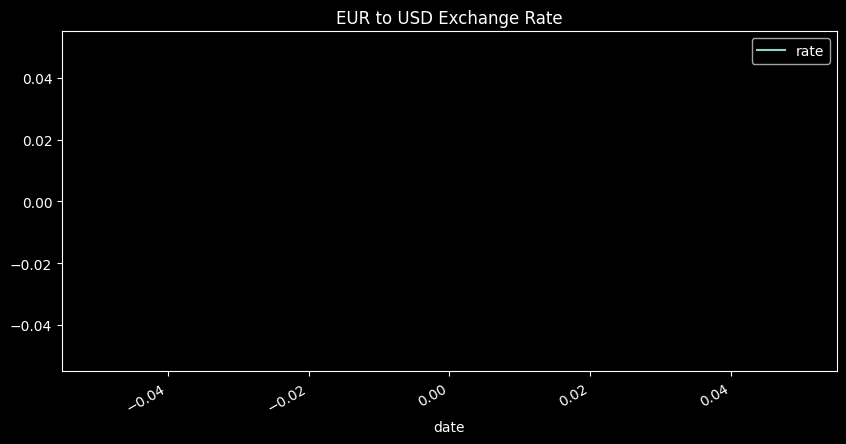

In [5]:
# Example: EUR to USD (adjust based on what you have)
df_pair = df[(df['curr_base'] == 'EUR') & (df['currency'] == 'USD')]

# Plot
df_pair.plot(x='date', y='rate', kind='line', title='EUR to USD Exchange Rate', figsize=(10, 5))


C:\Users\Tanel\AppData\Local\Temp\ipykernel_47592\354930451.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top = pd.read_sql(query, conn)


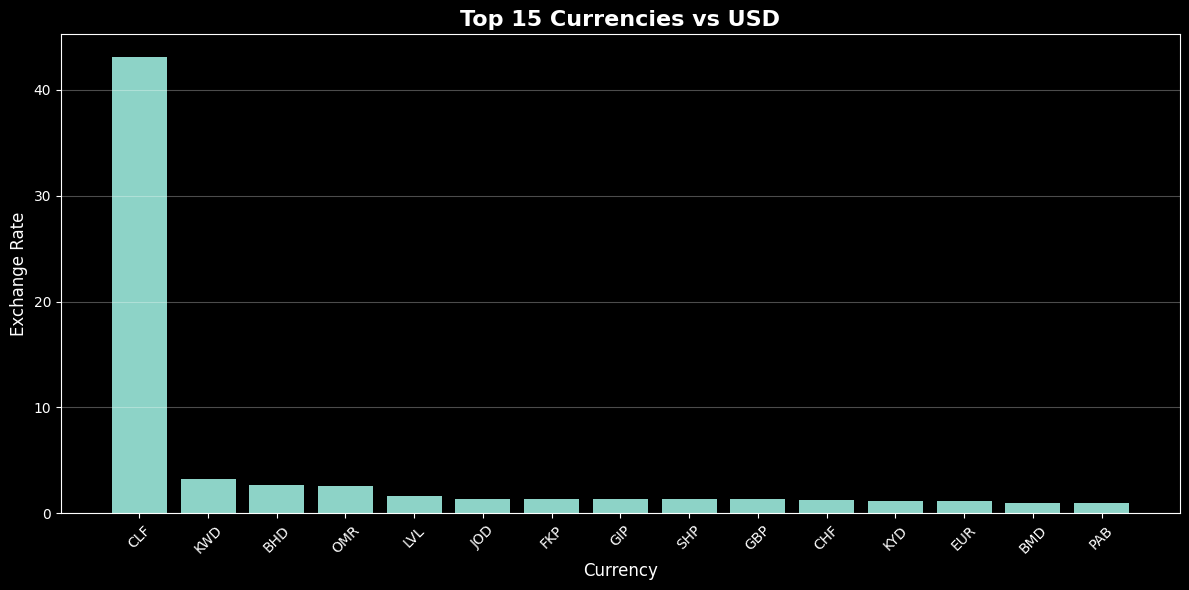

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

# Get top 15 currencies by rate against USD
query = """
SELECT f.curr_base, AVG(f.rate) as avg_rate
FROM public_gold.fact_rates f
WHERE f.currency = 'USD'
GROUP BY f.curr_base
ORDER BY avg_rate DESC
LIMIT 15
"""
df_top = pd.read_sql(query, conn)

# Create bar chart
plt.figure(figsize=(12, 6))
plt.bar(df_top['curr_base'], df_top['avg_rate'])
plt.title('Top 15 Currencies vs USD', fontsize=16, fontweight='bold')
plt.xlabel('Currency', fontsize=12)
plt.ylabel('Exchange Rate', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Time Series Analysis: Currency Volatility
Let's analyze which currencies show the most volatility against USD over time

C:\Users\Tanel\AppData\Local\Temp\ipykernel_47592\1933790437.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_time_series = pd.read_sql(query, conn)


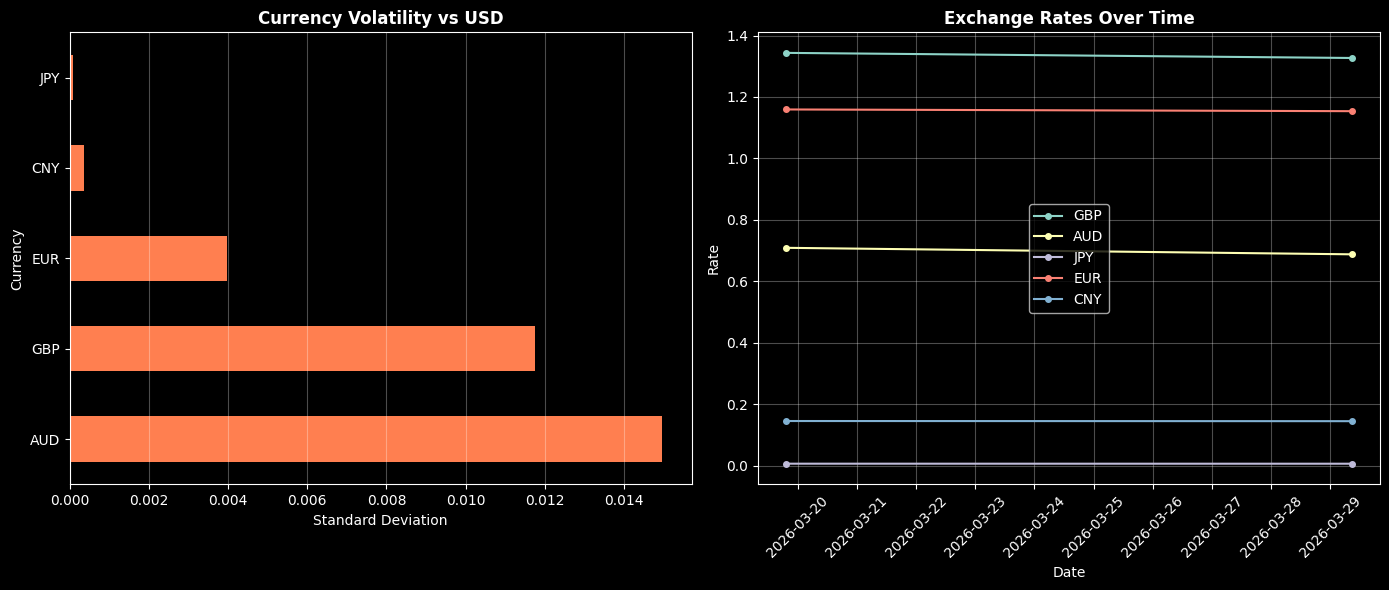

In [7]:
# Get time series data for multiple currencies
query = """
        SELECT d.date, f.curr_base, f.rate
        FROM public_gold.fact_rates f
                 JOIN public_gold.dim_date d ON f.date_key = d.date_key
        WHERE f.currency = 'USD'
          AND f.curr_base IN ('EUR', 'GBP', 'JPY', 'CNY', 'AUD')
        ORDER BY d.date, f.curr_base \
        """
df_time_series = pd.read_sql(query, conn)

# Calculate volatility (standard deviation) for each currency
volatility = df_time_series.groupby('curr_base')['rate'].std().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
volatility.plot(kind='barh', color='coral')
plt.title('Currency Volatility vs USD', fontweight='bold')
plt.xlabel('Standard Deviation')
plt.ylabel('Currency')
plt.grid(axis='x', alpha=0.3)

plt.subplot(1, 2, 2)
for currency in df_time_series['curr_base'].unique():
    data = df_time_series[df_time_series['curr_base'] == currency]
    plt.plot(data['date'], data['rate'], label=currency, marker='o', markersize=4)

plt.title('Exchange Rates Over Time', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Rate')
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Currency Correlation Matrix
Discover which currencies move together

C:\Users\Tanel\AppData\Local\Temp\ipykernel_47592\1780162921.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_corr = pd.read_sql(query, conn)


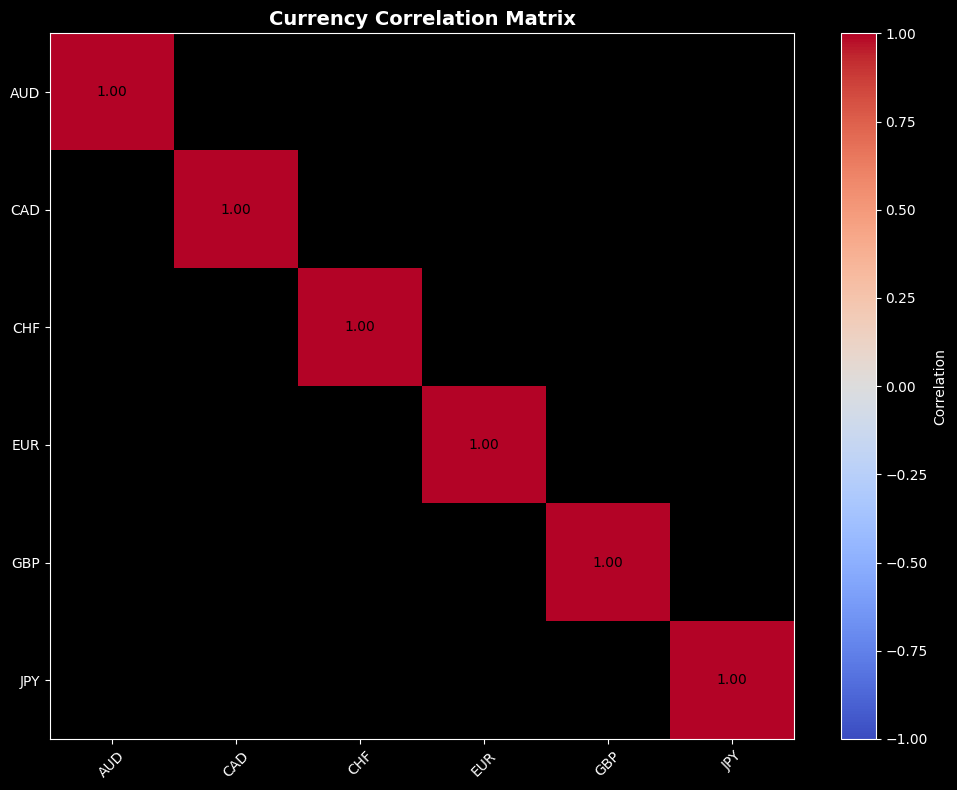

In [8]:
# Pivot data to get currencies as columns
query = """
        SELECT d.date, f.curr_base, f.rate
        FROM public_gold.fact_rates f
                 JOIN public_gold.dim_date d ON f.date_key = d.date_key
        WHERE f.currency = 'USD'
          AND f.curr_base IN ('EUR', 'GBP', 'JPY', 'CHF', 'AUD', 'CAD') \
        """
df_corr = pd.read_sql(query, conn)
df_pivot = df_corr.pivot(index='date', columns='curr_base', values='rate')

# Calculate correlation matrix
correlation = df_pivot.corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title('Currency Correlation Matrix', fontsize=14, fontweight='bold')

# Add correlation values
for i in range(len(correlation)):
    for j in range(len(correlation)):
        plt.text(j, i, f'{correlation.iloc[i, j]:.2f}',
                 ha='center', va='center', color='black', fontsize=10)

plt.tight_layout()
plt.show()

## Cross-Rate Calculator
Calculate exchange rates between any two currencies

In [10]:
def calculate_cross_rate(base_curr, target_curr, reference='USD'):
    """Calculate cross rate between two currencies using a reference currency"""
    query = f"""
    SELECT 
        b.rate as base_rate,
        t.rate as target_rate,
        (t.rate / b.rate) as cross_rate
    FROM 
        (SELECT rate FROM public_gold.fact_rates 
         WHERE curr_base = '{base_curr}' AND currency = '{reference}' LIMIT 1) b,
        (SELECT rate FROM public_gold.fact_rates 
         WHERE curr_base = '{target_curr}' AND currency = '{reference}' LIMIT 1) t
    """
    result = pd.read_sql(query, conn)

    if not result.empty:
        cross_rate = result['cross_rate'].iloc[0]
        print(f"1 {base_curr} = {cross_rate:.6f} {target_curr}")
        return cross_rate
    else:
        print(f"Could not calculate rate for {base_curr}/{target_curr}")
        return None


# Example usage
calculate_cross_rate('EUR', 'GBP')
calculate_cross_rate('JPY', 'CNY')
calculate_cross_rate('AUD', 'CAD')

1 EUR = 1.158853 GBP
1 JPY = 22.887238 CNY
1 AUD = 1.027992 CAD


C:\Users\Tanel\AppData\Local\Temp\ipykernel_47592\3404207248.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql(query, conn)
C:\Users\Tanel\AppData\Local\Temp\ipykernel_47592\3404207248.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql(query, conn)
C:\Users\Tanel\AppData\Local\Temp\ipykernel_47592\3404207248.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql(query, conn)


np.float64(1.027991725608906)

## Statistical Summary by Currency

In [11]:
query = """
        SELECT f.curr_base,
               COUNT(*)       as num_quotes,
               AVG(f.rate)    as avg_rate,
               MIN(f.rate)    as min_rate,
               MAX(f.rate)    as max_rate,
               STDDEV(f.rate) as std_rate
        FROM public_gold.fact_rates f
        WHERE f.currency = 'USD'
        GROUP BY f.curr_base
        ORDER BY num_quotes DESC
        LIMIT 20 \
        """
df_stats = pd.read_sql(query, conn)
df_stats['range'] = df_stats['max_rate'] - df_stats['min_rate']
df_stats.style.format({
    'avg_rate': '{:.6f}',
    'min_rate': '{:.6f}',
    'max_rate': '{:.6f}',
    'std_rate': '{:.6f}',
    'range': '{:.6f}'
})


C:\Users\Tanel\AppData\Local\Temp\ipykernel_47592\3450310019.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_stats = pd.read_sql(query, conn)


,curr_base,num_quotes,avg_rate,min_rate,max_rate,std_rate,range
0,CDF,2,0.000435,0.000433,0.000437,0.000003,0.000004
1,THB,2,0.030574,0.030385,0.030763,0.000267,0.000378
2,HKD,2,0.127726,0.127680,0.127772,0.000065,0.000092
3,IDR,2,0.000059,0.000059,0.000059,0.000000,0.000000
4,CLF,2,43.055048,42.675121,43.434975,0.537298,0.759854
5,TRY,2,0.022534,0.022502,0.022565,0.000044,0.000063
6,ETB,2,0.006373,0.006361,0.006385,0.000017,0.000023
7,ILS,2,0.319896,0.318069,0.321722,0.002583,0.003653
8,MOP,2,0.124006,0.123962,0.124051,0.000063,0.000089
9,SYP,2,0.009034,0.009019,0.009048,0.000020,0.000028


In [ ]:
%%sql
